In [3]:
# Add the parent directory of the current working directory to the Python path at runtime. 
# In order to import modules from the src directory.
import os
import sys 

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)

In [4]:
import glob
import torch

import tomllib
import random
import pandas as pd
import numpy as np
from copy import deepcopy

from scipy.optimize import nnls


from langchain_ollama import OllamaLLM
from langchain_core.prompts import PromptTemplate
from src.utils.load_and_save import load_embedding_shards, align_to_df
from src.utils.hypersphere import mean_angle, convert_to_cartesian, convert_to_polar
from src.classes.sparse_embedding_network import SparseEmbeddingNetwork
from langchain_voyageai.embeddings import VoyageAIEmbeddings
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())
voyage_api_key = os.environ["VOYAGE_API_KEY"]

BASEPATH = os.environ["BASEPATH"]

/home/mario/miniconda3/envs/trends_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
def parse_directories():
    """
    Parse the directories from the configuration file.
    Returns:
    - directories: dict
    """
    with open('../config/directories.toml', 'rb') as f:
        configurations = tomllib.load(f)

    return configurations

In [6]:
directories = parse_directories()
csv_path = os.path.join(BASEPATH, directories['public']['csv'])
hdf5_path = os.path.join(BASEPATH, directories['public']['hdf5'])
model_path = os.path.join(BASEPATH, directories['public']['models'])
article_file = os.path.join(csv_path, "neuroscience_articles_1999-2023.csv")
model_file = os.path.join(model_path, "domain_embedding_model.pth")
hdf5_files = glob.glob(os.path.join(hdf5_path, "*.h5"))

In [7]:
article_df = pd.read_csv(article_file)

research_df = article_df[article_df['Type'] == 'Research'].copy()
research_pmids = research_df['Pmid'].unique()

In [8]:
embeddings, pmids = load_embedding_shards(hdf5_files)
embeddings, pmids = align_to_df(embeddings, pmids, article_df)

100%|██████████| 2307/2307 [01:26<00:00, 26.72it/s]


In [9]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [10]:
anchor_abstract = """ 
Understanding the functional architecture of complex systems is crucial to illuminate their inner workings and enable effective methods for their prediction and control. Recent advances have introduced tools to characterise emergent macroscopic levels; however, while these approaches are successful in identifying when emergence takes place, they are limited in the extent they can determine how it does. Here we address this limitation by developing a computational approach to emergence, which characterises macroscopic processes in terms of their computational capabilities. Concretely, we articulate a view on emergence based on how software works, which is rooted on a mathematical formalism that articulates how macroscopic processes can express self-contained informational, interventional, and computational properties. This framework establishes a hierarchy of nested self-contained processes that determines what computations take place at what level, which in turn delineates the functional architecture of a complex system. This approach is illustrated on paradigmatic models from the statistical physics and computational neuroscience literature, which are shown to exhibit macroscopic processes that are akin to software in human-engineered systems. Overall, this framework enables a deeper understanding of the multi-level structure of complex systems, revealing specific ways in which they can be efficiently simulated, predicted, and controlled.
"""

In [11]:
batch_size = 25
voyage_embedder = VoyageAIEmbeddings(model='voyage-large-2-instruct', batch_size=batch_size,
                                         voyage_api_key=voyage_api_key)

In [12]:
# define the model and load the pre-trained weights
input_dimension = 1024
hidden_dimensions =  [512, 256, 128]
output_dimension = 64

model = SparseEmbeddingNetwork(input_dimension=input_dimension,
                                 hidden_dimensions=hidden_dimensions,
                                 output_dimension=output_dimension).to(device)

model.load_state_dict(torch.load(model_file, map_location=device))
model.eval()

SparseEmbeddingNetwork(
  (first_stage): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): Dropout(p=0.05, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ELU(alpha=1.0)
  )
  (second_stage): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): Dropout(p=0.05, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
  )
)

In [13]:
def embed_abstracts(abstracts, voyage_embedder, model, device, batch_size=25):
    """
    Embed a list of abstracts using the VoyageAI embedder and the sparse embedding model.

    Args:
    - abstracts: List of abstracts to embed.
    - voyage_embedder: The VoyageAI embedder to use.
    - model: The sparse embedding model to use.
    - device: The device to use (CPU or GPU).

    Returns:
    - embeddings: Numpy array of embeddings.
    """

    num_abstracts = len(abstracts)
    all_embeddings = []
    for i in range(0, num_abstracts, batch_size):
        batch_abstracts = abstracts[i:i+batch_size]
        batch_embeddings = voyage_embedder.embed_documents(batch_abstracts)
        batch_embeddings = torch.tensor(batch_embeddings, dtype=torch.float32).to(device)
        with torch.no_grad():
            batch_embeddings = model(batch_embeddings).cpu().numpy()
        all_embeddings.append(batch_embeddings)

    embeddings = np.vstack(all_embeddings)
    return embeddings

In [14]:
other_disc_file = '/media/mario/HDD/Data/NeuroScape/Internal/Intermediate/CSV/OtherDisciplines/merged.csv'
other_disc_article_df = pd.read_csv(other_disc_file)
other_disc_abstracts = other_disc_article_df['Abstract'].tolist()
other_disc_embeddings = embed_abstracts(other_disc_abstracts, voyage_embedder, model, device)

In [15]:
augmented_embeddings = np.vstack((embeddings, other_disc_embeddings))
augmented_article_df = pd.concat([article_df, other_disc_article_df], ignore_index=True)
augmented_abstracts = augmented_article_df['Abstract'].tolist()
augmented_pmids = augmented_article_df['Pmid'].values

In [356]:
# embeddings: (N, d), unit-normalized
N, d = embeddings.shape

# random initialization on sphere
x = np.random.randn(d)
x /= np.linalg.norm(x)

# 
#x = deepcopy(most_remote_embedding)

eta = 0.05
num_steps = 3000

for step in range(num_steps):
    sims = embeddings @ x          # (N,)
    #sims[remote_idx] = 0
    j = np.argmax(sims)           # index of closest (max similarity)
    max_sim = sims[j]

    if max_sim <= 0.5:
        break
    
    # subgradient descent step to reduce max_sim
    grad = embeddings[j]          # subgradient of max dot product
    x = x - eta * grad
    x /= np.linalg.norm(x)

    # optional: decay step size
    eta *= 0.999

sims = embeddings @ x          # (N,)
#sims[remote_idx] = 0
j = np.argmax(sims)           # index of closest (max similarity)
max_sim = sims[j]
print("Final min-possible max similarity:", max_sim)

Final min-possible max similarity: 0.48597400864960705


In [360]:
true_target_abstract = """The localization of electrons caused by atomic disorder is a well-known phenomenon. However, under which circumstances electrons remain delocalized and retain band-like characteristics even when the crystal structure is completely absent, as found in certain amorphous solids, is less well understood. Here, to probe this phenomenon, we develop a fully first-principles description of the electronic structure and charge transport in amorphous materials, which combines a representation of the amorphous state as a composite (ensemble) of local environments and the state-of-the-art many-body electronic structure methods. Using amorphous In2O3 as an example, we demonstrate the accuracy of our approach in reproducing the band-like nature of the conduction electrons as well as their disorder-limited mobility. Our approach reveals the physical origins responsible for the electron delocalization and survival of the band dispersions despite the absence of long-range order."""


true_target_abstract = """Gamma synchrony is ubiquitous in visual cortex, but whether it contributes to perceptual grouping remains contentious based on observations that gamma frequency is not consistent across stimulus features and that gamma synchrony depends on distances between image elements. These stimulus dependencies have been argued to render synchrony among neural assemblies encoding components of the same object difficult. Alternatively, these dependencies may shape synchrony in meaningful ways. Indeed, according to the theory of weakly coupled oscillators (TWCO), synchrony-based grouping mechanisms would require stimulus dependence. Synchronization among coupled oscillators depends on frequency dissimilarity and coupling strength, which in early visual cortex relate to local feature dissimilarity and physical distance, respectively. We manipulated these factors in a texture segregation experiment wherein human observers identified the orientation of a figure defined by reduced contrast heterogeneity compared to the background. Human performance followed TWCO predictions both qualitatively and quantitatively, as formalized in a computational model. Moreover, we found that when enriched with a Hebbian learning rule, our model also predicted human learning effects. Increases in model gamma synchrony due to perceptual learning predicted improvements in behavioral performance across sessions. This suggests that the stimulus-dependence of gamma synchrony is adaptable to the statistics of visual experiences, providing a viable neural grouping mechanism that can improve with visual experience. Together our results suggest that gamma synchrony can indeed play a functional role in visual scene segmentation and offer a plausible mechanistic explanation for its stimulus-dependent variability."""



true_target_embedding = embed_abstracts([true_target_abstract], voyage_embedder, model, device)[0]

true_target_embedding = deepcopy(x)

similarity = augmented_embeddings.dot(true_target_embedding.T).ravel()

seed_abstract_index = np.argmax(similarity)
#seed_abstract_index = np.where((similarity < 0.3) & (similarity > 0.2))[0][0]

seed_abstract = augmented_article_df.iloc[seed_abstract_index]['Abstract']
seed_embedding = augmented_embeddings[seed_abstract_index]

print(similarity[seed_abstract_index])
print(similarity.max())

0.48597400864960705
0.48597400864960705


In [256]:
seed_abstract = """This work investigates the necessary preconditions for human knowledge, proposing that cognition arises from the interaction between a priori mental structures and empirical sensory input. Contrary to models in which knowledge derives exclusively from experience or innate rational intuition, the analysis partitions cognition into sensibility (the capacity to receive data) and understanding (the capacity to process data via conceptual rules). Sensible intuitions are structured by two inherent spatiotemporal forms, while the understanding applies a finite set of a priori categories that enable synthetic judgments. The study argues that such judgments—particularly synthetic a priori ones—provide the foundation for mathematics, natural science, and the possibility of objective experience.

A critical distinction is drawn between phenomena, which are objects as they appear under these cognitive conditions, and noumena, which lie beyond possible experience and are therefore epistemically inaccessible. Attempts by prior metaphysical systems to derive knowledge of noumenal entities (e.g., the soul, the cosmos as totality, or God) are shown to result in antinomies produced by misapplication of the categories beyond empirical boundaries. The proposed system thus limits speculative metaphysics while justifying empirical science by explaining how universal and necessary laws arise from cognition rather than nature in itself.

These findings establish a transcendental methodology that reframes metaphysics not as knowledge of supersensible entities, but as analysis of the structural conditions enabling knowledge, experience, and scientific inquiry."""

seed_abstract = """We report a qualitative observational case study conducted during a single nocturnal interval in late December, examining the cognitive and emotional responses of a solitary human subject exposed to repeated acoustic stimuli originating from an unidentified avian entity. The subject, initially engaged in low-arousal literary analysis, detected a periodic external stimulus misattributed to human visitation. Subsequent visual inspection revealed a Corvus-like organism exhibiting atypical locomotive behavior (i.e., stationary perching on a classical bust) and limited but consistent vocal output, consisting exclusively of the phoneme sequence “Nevermore.”

Behavioral analysis suggests that semantic fixation on the subject’s deceased conspecific (Lenore) interacted with the bird’s repetitive utterance to induce escalating psychological dysregulation, including rumination, existential inquiry, and despair. Attempts to interpret the vocalization as communicative, prophetic, or divinely sourced correlated with heightened emotional distress and perceived supernatural causation. The organism demonstrated no observed variation in vocal repertoire, kinetic activity, or empathetic response, indicating stimulus independence from subject affect.

The event culminated in long-term depressive entrenchment marked by a persistent perception of the organism’s presence and a self-reported inability to achieve emotional recovery (“nevermore”). Findings suggest that exposure to symbolically charged corvid stimuli may exacerbate grief-related cognitive loops in isolated individuals. Further research is needed to determine whether the bird exhibits intentional communicative behavior or functions solely as a catalyst for endogenous psychological decline."""

seed_abstract = """Peripheral neurotoxicity is a dose-limiting adverse reaction of primary frontline chemotherapeutic agents, including vincristine. Neuropathy can be so disabling that patients drop out of potentially curative therapy, negatively impacting cancer prognosis. The hallmark of vincristine neurotoxicity is axonopathy, yet its underpinning mechanisms remain uncertain. We developed a comprehensive drug discovery platform to identify neuroprotective agents against vincristine-induced neurotoxicity. Among the hits identified, SIN-1—an active metabolite of molsidomine—prevents vincristine-induced axonopathy in both motor and sensory neurons without compromising vincristine anticancer efficacy. Mechanistically, we found that SIN-1’s neuroprotective effect is mediated by activating soluble guanylyl cyclase. We modeled vincristine-induced peripheral neurotoxicity in rats to determine molsidomine therapeutic potential in vivo. Vincristine administration induced severe nerve damage and mechanical hypersensitivity that were attenuated by concomitant treatment with molsidomine. This study provides evidence of the neuroprotective properties of molsidomine and warrants further investigations of this drug as a therapy for vincristine-induced peripheral neurotoxicity."""


seed_embedding = embed_abstracts([seed_abstract], voyage_embedder, model, device)[0]

In [343]:
best

{'abstracts': ["Background noise is the irregular variation across repeated measurements of human performance. Background noise remains after task and treatment effects are minimized. Background noise refers to intrinsic sources of variability, the intrinsic dynamics of mind and body, and the internal workings of a living being. Two experiments demonstrate 1/f scaling (pink noise) in simple reaction times and speeded word naming times, which round out a catalog of laboratory task demonstrations that background noise is pink noise. Ubiquitous pink noise suggests processes of mind and body that change each other's dynamics. Such interaction-dominant dynamics are found in systems that self-organize their behavior. Self-organization provides an unconventional perspective on cognition, but this perspective closely parallels a contemporary interdisciplinary view of living systems.",
  'Background noise is the irregular variation across repeated measurements of human performance. This noise p

In [18]:
POSITIVE_STEP_PROMPT = PromptTemplate(
    input_variables=["x_best_text", "x_direction_text"],
    template="""
            You are an AI assistant tasked with refining a scientific abstract to move it closer to a target concept in embedding space.

            You are given two pieces of text:
            1.  The "Current Best" abstract, which is our strongest candidate so far.
            2.  The "Direction Abstract," which contains the key themes and concepts needed to improve the "Current Best."

            The Direction Abstract represents the target conceptual space. Increase the overlap in methods and key biological entities with the Direction Abstract.

            **Current Best Abstract:**
            {x_best_text}

            **Direction Abstract:**
            {x_direction_text}

            **Instructions:**
            Your goal is to create a new, single, coherent abstract by synthesizing these two. The new abstract should:
            1.  Keep some of the content of the "Current Best" abstract, but make a big step towards incorporating the ideas/methodologies from the "Direction Abstract." 
            2.  Integrate the key scientific concepts, methodology, or conclusions from the "Direction Abstract."
            3.  NOT be a simple copy of either abstract. It must be a logical and plausible fusion, as if you are editing the "Current Best" using ideas from the "Direction Abstract."
            
            Do NOT write about “groundbreaking,” “unprecedented,” or “innovative model” claims.
            Do NOT write nonsense. Try to make as much conceptual and scientific sense as possible. You are allowed to make up plausible results and conclusions.

            Do NOT just rephrase the "Current Best" abstract. The goal is to move it towards concepts in the "Direction Abstract."
            You may change or replace multiple sentences, introduce new methods or results,
            and restructure the narrative, as long as the abstract remains coherent and scientific.
            You ARE allowed to drop concepts from the "Current Best" abstract if they do not help move it towards the "Direction Abstract."

            The abstract must not exceed 200 words.

            Return only the new, synthesized abstract.
            """,
)

NEGATIVE_STEP_PROMPT = PromptTemplate(
    input_variables=["x_best_text", "x_direction_text"],
    template="""
            You are an AI assistant tasked with refining a scientific abstract to move it away from concepts that are opposite to a desired target.

            You are given two pieces of text:
            1.  The "Current Best" abstract, which is our strongest candidate so far.
            2.  The "Direction Abstract," which represents scientific themes and concepts that lie in the opposite direction of where we ultimately want to be.

            **Current Best Abstract:**
            {x_best_text}

            **Direction Abstract (Opposite-of-Target):**
            {x_direction_text}

            Instructions:
            Your goal is to create a new, single, coherent abstract that:
            1. That keeps most of the content of the "Current Best" abstract.
            2. Identifies and removes or replaces themes, methods, or conclusions that resemble those in the "Direction Abstract," especially when they conflict conceptually with the likely target direction.
            3. Preserves scientific plausibility and coherence, and if content must be replaced, use alternative but reasonable mechanisms, results, or interpretations rather than leaving gaps.

            Do NOT write about “groundbreaking,” “unprecedented,” or “innovative model” claims.
            Do NOT write nonsense. You are allowed to make up plausible results and conclusions, but keep them generic and reasonable.

            Do NOT just rephrase the "Current Best" abstract. The goal is to move it away from concepts in the "Direction Abstract."
            You may change or replace multiple sentences, introduce new methods or results,
            and restructure the narrative, as long as the abstract remains coherent and scientific.
            You ARE allowed to drop concepts from the "Current Best" abstract if they closely resemble those in the "Direction Abstract."

            The abstract must not exceed 200 words.

            Return only the new, refined abstract.
            """,
)

DUAL_STEP_PROMPT = PromptTemplate(
    input_variables=["x_best_text", "x_positive_direction_text", "x_negative_direction_text"],
    template="""
            You are an AI assistant tasked with refining a scientific abstract to move it closer to a target concept in embedding space while simultaneously moving it away from concepts that are opposite to the desired target.
            Clearly concepts that are present in both the positive and negative direction abstracts are least relevant to be changed.
            Those concepts unique to the positive direction abstract are most important to be added.
            Those concepts unique to the negative direction abstract are most important to be removed.

            You are given three pieces of text:
            1. The "Current Best" abstract, which is our strongest candidate so far.
            2. The "Positive Direction Abstract," which represents scientific themes and concepts that lie in the direction of the desired target.
            3. The "Negative Direction Abstract," which represents scientific themes and concepts that lie in the opposite direction of the desired target.

            **Current Best Abstract:**
            {x_best_text}

            **Positive Direction Abstract:**
            {x_positive_direction_text}

            **Negative Direction Abstract:**
            {x_negative_direction_text}

            Instructions:
            Your goal is to create a new, single, coherent abstract that:
            1. Moves the "Current Best" abstract closer to the "Positive Direction Abstract."
            2. Moves the "Current Best" abstract away from the "Negative Direction Abstract."
            3. Preserves scientific plausibility and coherence.

            The abstract must not exceed 200 words.

            Return only the new, synthesized abstract.
            """,
)

llm = OllamaLLM(model="gemma2:9b")
positive_step_chain = POSITIVE_STEP_PROMPT | llm
negative_step_chain = NEGATIVE_STEP_PROMPT | llm
dual_step_chain = DUAL_STEP_PROMPT | llm

In [345]:
def get_error_abstract(target_embedding, best_embedding, article_df, embeddings, direction='positive'):
    
    if direction == 'negative':
        error = best_embedding - target_embedding
    else:
        error = target_embedding - best_embedding.dot(target_embedding) *  best_embedding


    error /= np.sqrt(error.dot(error))

    similarity = embeddings.dot(error.T).flatten()

    most_similar_index = np.argmax(similarity)
    most_similar_abstract = article_df.iloc[most_similar_index]['Abstract']

    return most_similar_abstract

def positive_step(best_abstract, best_embedding, target_embedding, article_df, embeddings, positive_step_chain):
    """
    Perform corrective synthesis generation using the top k abstracts and their similarities.
    
    Args:
    - best_abstract: The best abstract.
    - best_embedding: The embedding of the best abstract.
    - target_embedding: The target embedding.
    - article_df: The article dataframe.
    - embeddings: The embeddings array.
    - correction_chain: The correction chain to use.
    - num_abstracts: Number of corrected abstracts to generate.
    
    Returns:
    - response: The response from the correction chain. A single corrected abstract.
    """

    direction_abstract = get_error_abstract(target_embedding, best_embedding, article_df, embeddings)
    response = positive_step_chain.invoke({'x_best_text': best_abstract,
                                       'x_direction_text': direction_abstract})
    return response.replace("\n", " ").replace("  ", " ").strip()

def negative_step(best_abstract, best_embedding, target_embedding, article_df, embeddings, negative_step_chain):
    """
    Perform corrective synthesis generation using the top k abstracts and their similarities.
    
    Args:
    - best_abstract: The best abstract.
    - best_embedding: The embedding of the best abstract.
    - target_embedding: The target embedding.
    - article_df: The article dataframe.
    - embeddings: The embeddings array.
    - correction_chain: The correction chain to use.
    - num_abstracts: Number of corrected abstracts to generate.
    
    Returns:
    - response: The response from the correction chain. A single corrected abstract.
    """

    direction_abstract = get_error_abstract(target_embedding, best_embedding, article_df, embeddings, direction='negative')

    response = negative_step_chain.invoke({'x_best_text': best_abstract,
                                       'x_direction_text': direction_abstract})
    return response.replace("\n", " ").replace("  ", " ").strip()

def dual_step(best_abstract, best_embedding, target_embedding, article_df, embeddings,
              positive_step_chain, negative_step_chain):
    """
    Perform dual corrective synthesis generation using the top k abstracts and their similarities.
    
    Args:
    - best_abstract: The best abstract.
    - best_embedding: The embedding of the best abstract.
    - target_embedding: The target embedding.
    - article_df: The article dataframe.
    - embeddings: The embeddings array.
    - correction_chain: The correction chain to use.
    - num_abstracts: Number of corrected abstracts to generate.
    
    Returns:
    - response: The response from the correction chain. A single corrected abstract.
    """

    positive_direction_abstract = get_error_abstract(target_embedding, best_embedding, article_df, embeddings, direction='positive')

    negative_direction_abstract = get_error_abstract(target_embedding, best_embedding, article_df, embeddings, direction='negative')

    response = dual_step_chain.invoke({'x_best_text': best_abstract,
                                       'x_positive_direction_text': positive_direction_abstract,
                                       'x_negative_direction_text': negative_direction_abstract})
    return response.replace("\n", " ").replace("  ", " ").strip()

def walk(best_abstract, best_embedding, target_embedding, article_df, embeddings,
              positive_step_chain, negative_step_chain, num_steps=5):

    candidate_abstract = dual_step(best_abstract, best_embedding, target_embedding, augmented_article_df, augmented_embeddings,
                                  positive_step_chain, negative_step_chain)

    candidate_embedding = embed_abstracts([candidate_abstract], voyage_embedder, model, device)[0]

    for _ in range(num_steps-1):
        
        candidate_abstract = dual_step(candidate_abstract, candidate_embedding, target_embedding, augmented_article_df, augmented_embeddings,
                                  positive_step_chain, negative_step_chain)
                                
        candidate_embedding = embed_abstracts([candidate_abstract], voyage_embedder, model, device)[0]

    return candidate_abstract, candidate_embedding



In [351]:
alpha = 1.0
temperature = 0.01
num_iterations = 200
current_abstract = deepcopy(seed_abstract)
current_embedding = deepcopy(seed_embedding)
###
current_abstract = deepcopy(best['abstracts'][-1])
current_embedding = embed_abstracts([current_abstract],voyage_embedder, model, device)[0]
###

target_embedding = (1 - alpha) * seed_embedding + alpha * true_target_embedding
target_embedding /= np.linalg.norm(target_embedding)
current_similarity = current_embedding.dot(target_embedding.T).item()
print(f"Initial target similarity: {current_similarity}")
true_similarity = current_embedding.dot(true_target_embedding.T).item()
print(f"Initial true similarity: {true_similarity}")

for iteration in range(num_iterations):
    
    print(f"Iteration {iteration}")
    
    """
    # dual step
    candidate_abstract = dual_step(current_abstract, current_embedding, target_embedding, augmented_article_df, augmented_embeddings,
                                  positive_step_chain, negative_step_chain)
    
    candidate_embedding = embed_abstracts([candidate_abstract], voyage_embedder, model, device)[0]
    """

    candidate_abstract, candidate_embedding = walk(current_abstract, current_embedding, target_embedding, augmented_article_df, augmented_embeddings,
                                  positive_step_chain, negative_step_chain, num_steps=1)

    # Evaluate candidate
    candidate_similarity = candidate_embedding.dot(target_embedding.T).item()

    similarity_diff = candidate_similarity - current_similarity
    acceptance_prob = min(1, np.exp(similarity_diff / temperature))
    random_number = np.random.rand()

    if random_number < acceptance_prob:
        current_abstract = candidate_abstract
        current_embedding = candidate_embedding
        current_similarity = candidate_similarity
        true_similarity = current_embedding.dot(true_target_embedding.T).item()
        print(f"Current target similarity: {current_similarity}")
        print(f"Current true similarity: {true_similarity}")
        print("Current abstract:")
        print(current_abstract)



    # increase alpha
    if current_similarity > 0.9:
        alpha = np.min([alpha + 0.05, 1.0])
        #temperature = 0.01
        target_embedding = (1 - alpha) * seed_embedding + alpha * true_target_embedding
        target_embedding /= np.linalg.norm(target_embedding)
        current_similarity = current_embedding.dot(target_embedding.T).item()
        print(f"Increasing alpha to {alpha}")

    if true_similarity > 0.95:
        break

    temperature *= 0.95
        


Initial target similarity: 0.7897440750703122
Initial true similarity: 0.7897440750703121
Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19
Iteration 20
Iteration 21
Iteration 22
Iteration 23
Iteration 24
Iteration 25
Iteration 26
Iteration 27
Iteration 28


KeyboardInterrupt: 

In [350]:
seed_abstract

"Background noise is the irregular variation across repeated measurements of human performance. Background noise remains after task and treatment effects are minimized. Background noise refers to intrinsic sources of variability, the intrinsic dynamics of mind and body, and the internal workings of a living being. Two experiments demonstrate 1/f scaling (pink noise) in simple reaction times and speeded word naming times, which round out a catalog of laboratory task demonstrations that background noise is pink noise. Ubiquitous pink noise suggests processes of mind and body that change each other's dynamics. Such interaction-dominant dynamics are found in systems that self-organize their behavior. Self-organization provides an unconventional perspective on cognition, but this perspective closely parallels a contemporary interdisciplinary view of living systems."

In [214]:
batch_size = 1000
num_total = embeddings.shape[0]
remote = {'index': [], 'similarity': []}
current_lowest = 99

for lower in range(0, num_total, batch_size):
    upper = np.minimum(lower + batch_size, num_total)
    similarities = embeddings.dot(embeddings[lower:upper].T)

    num_items = upper-lower
    similarities[lower:upper] = similarities[lower:upper] - np.eye(num_items)

    minimax = np.max(similarities,axis=0)

    remote['index'].append(np.argmin(minimax) + lower)
    remote['similarity'].append(minimax.min())

    lowest = minimax.min()
    if lowest < current_lowest:
        current_lowest = lowest

    print(f'current lowest: {current_lowest}')
    if minimax.min() < 0.5:
        break






current lowest: 0.6202069439845797
current lowest: 0.5800738454684163
current lowest: 0.5800738454684163
current lowest: 0.5651166978120552
current lowest: 0.5651166978120552
current lowest: 0.5651166978120552
current lowest: 0.5651166978120552
current lowest: 0.5651166978120552
current lowest: 0.5651166978120552
current lowest: 0.5651166978120552
current lowest: 0.5651166978120552
current lowest: 0.5651166978120552
current lowest: 0.5651166978120552
current lowest: 0.5651166978120552
current lowest: 0.5651166978120552
current lowest: 0.5651166978120552
current lowest: 0.5651166978120552
current lowest: 0.5547568604466357
current lowest: 0.5547568604466357
current lowest: 0.5547568604466357
current lowest: 0.5547568604466357
current lowest: 0.5547568604466357
current lowest: 0.5547568604466357
current lowest: 0.5547568604466357
current lowest: 0.5547568604466357
current lowest: 0.5547568604466357
current lowest: 0.5547568604466357
current lowest: 0.5547568604466357
current lowest: 0.55

In [329]:
remote_abstracts = []

for idx in remote['index']:
    abstract = article_df.iloc[idx]['Abstract']
    remote_abstracts.append(abstract)
    print(abstract)
    print('----------------------')

Receptor-associated protein appears to play an important role in low-density lipoprotein receptor-related protein trafficking. Since ligands for the low-density lipoprotein receptor-related protein have been implicated in Alzheimer's disease and normal functioning of this protein is indispensable for central nervous system development, deficient receptor-associated protein expression may result in central nervous system alterations. In this study, receptor-associated protein knockout mice were behaviorally tested and nervous system integrity was assessed via in situ hybridization and immunocytochemical/laser confocal microscopy methods. Receptor-associated protein knockout mice were found to be cognitively impaired in the Morris water maze compared to controls. In wild-type mice, the receptor-associated protein was found to be highly co-expressed with somatostatin in hippocampal and neocortical inhibitory neurons. Receptor-associated protein knockout mice, however, showed a significant

In [354]:

remote_idx = remote['index'][58]
most_remote_embedding = embeddings[remote_idx]
article_df.iloc[remote_idx]['Pmid']

np.int64(13678372)

In [287]:
i = np.argmin(remote['similarity'])
remote_idx = remote['index'][i]
most_remote_embedding = embeddings[remote_idx]

0.9999999487916722


'Vertebrate eye movements depend on the co-ordinated function of six extraocular muscles that are innervated by the oculomotor, trochlear, and abducens nerves. Here, we show that the diffusible factors, stromal cell-derived factor-1 (SDF-1) and hepatocyte growth factor (HGF), guide the development of these axon projections. SDF-1 is expressed in the mesenchyme around the oculomotor nerve exit point, and oculomotor axons fail to exit the neuroepithelium in mice mutant for the SDF-1 receptor CXCR4. Both SDF-1 and HGF are expressed in or around the ventral and dorsal oblique muscles, which are distal targets for the oculomotor and trochlear nerves, respectively, as well as in the muscles which are later targets for oculomotor axon branches. We find that in vitro SDF-1 and HGF promote the growth of oculomotor and trochlear axons, whereas SDF-1 also chemoattracts oculomotor axons. Oculomotor neurons show increased branching in the presence of SDF-1 and HGF singly or together. HGF promotes t

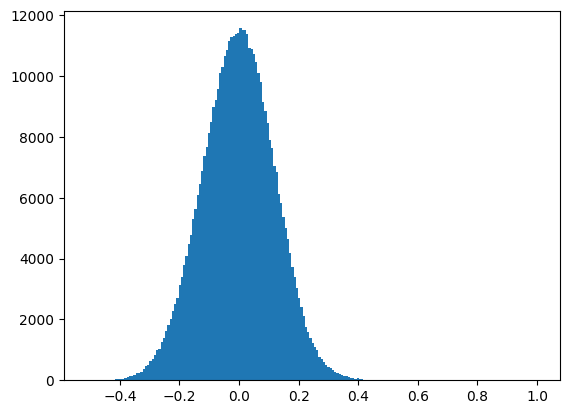

In [ ]:
sims = embeddings.dot(embeddings[remote_idx].T).flatten()
sims[remote_idx] = 0


print(sims.max())
plt.hist(sims,200);

article_df.iloc[remote_idx]['Abstract']


In [209]:
sims = embeddings.dot(embeddings[remote_ids].T)
np.argmin(sims,axis=0)

array([135221, 199986, 285380, 219072, 457192,  98054, 417422,  14546,
       371459, 423636, 428358, 364262, 416818, 384181, 396185, 316038,
       194755, 405636,  77069, 126624, 196103, 407835, 159274, 372817,
       204350, 363771, 401103,  50175, 292834, 349123, 444819,  81211,
       250920,  92590, 224299,  99860, 158406, 240511, 173363, 423434,
       239987, 427385, 450114, 354537, 354624, 447753, 167326, 341952,
        86121, 302470, 300707, 441204, 212212, 433011, 374353, 282225,
       288406, 371073, 291620, 312128, 406576, 193590, 293199, 343570,
       329982,  53333, 370850,  59854, 278714, 277588, 319999,  13861,
       258904, 399648, 293997,  46223, 455620, 283081, 137217, 433934,
       116184, 396360, 157203, 408018, 136896, 124695, 436375, 168515,
       454198, 428475, 143954,  48751, 104155, 397567, 125859, 322574,
       417628, 285794, 128065, 238521,  59632, 327232, 272923, 292698,
         2096, 366000, 278526, 216976, 260098, 381912, 399498, 244873,
      

0.5789245673776142


np.int64(38049798)

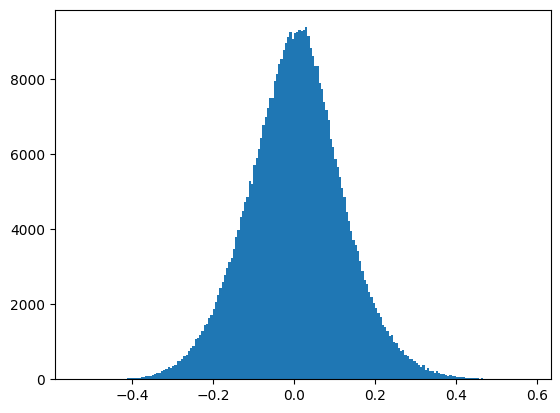

In [353]:
idx  = remote_ids[-1]



sims = embeddings.dot(embeddings[idx].T).flatten()
sims[idx] = 0
print(sims.max())
plt.hist(sims,200);

article_df.iloc[idx]['Pmid']

----------------------------------------------------

----------------------------------------------------

In [ ]:
# 1) Similarity (dot product). If your embeddings aren't L2-normalized, see cosine variant below.
similarity = embeddings.dot(true_target_embedding.T).ravel()  # shape: (N,)

# 2) Top-K indices in descending order (fast & memory-friendly)
top_k = 500
idx = np.argpartition(similarity, -top_k)[-top_k:]             # unsorted top-K
top_k_indices = idx[np.argsort(similarity[idx])[::-1]]         # sort those K by score desc

# 3) Get top-K embeddings
top_k_embeddings   = embeddings[top_k_indices]

# 4) Non-negative least squares to find weights
w, _ = nnls(top_k_embeddings.T, true_target_embedding)
s = w.sum()
if s > 0: 
    w = w / s

# 5) Mixture & renormalize
anchor_embedding = w @ top_k_embeddings
anchor_embedding /= np.linalg.norm(anchor_embedding)

In [268]:
CROSSOVER_PROMPT = PromptTemplate(
    input_variables=["abstract_A_text", "abstract_B_text"],
    template="""
            Your task is to create a new, plausible scientific abstract by performing a "conceptual crossover" between the two parent abstracts below. This involves applying the methodology of one abstract to the problem domain of the other.

            **[Abstract A]**
            {abstract_A_text}

            **[Abstract B]**
            {abstract_B_text}

            **Instructions:**
            1.  Identify the core **problem**, **research question** or **hypothesis** being investigated in **Abstract A**.
            2.  Identify the core **methodology** or **approach** used in **Abstract B**.
            3.  Write a completely new, coherent abstract for a hypothetical study that applies the **methodology from Abstract B** to investigate the **problem/question/hypothesis from Abstract A**.
            4.  You will need to invent plausible results and a conclusion that logically follow from this combination. The goal is to create a high-quality "child" abstract that logically inherits these specific conceptual traits from its "parents."  
            5.  You can drop or modify existing concepts as needed to ensure coherence.

            Abstracts must have empirical specificity, methodological coherence, and conceptual restraint. Avoid “groundbreaking,” “unprecedented,” “innovative model” claims.
            Do NOT write nonsense. Try to make as much conceptual and scientific sense as possible. You are allowed to make up plausible results and conclusions.

            The abstract must not exceed 200 words. Remove all unnecessary Line Feeds. Remove all Line Feeds at the end of the abstract.

            Return only the new, conceptually fused abstract. No other text, comments, or explanations. 
            """,
)

In [269]:
MUTATION_PROMPT = PromptTemplate(
    input_variables=["abstract_text"],
    template="""

            There are 8 dimensions of neuroscientific research:
            1. Appliedness: The extent to which the research is basic science (fundamental mechanisms) or applied (translational, clinical, legal, neuroeconomics, method development, advancing technology).
            2. Modality: The sensory and/or motor modality under investigation (e.g., visual, auditory, gustatory, somatosensory, motor, sensorimotor, multimodal).
            3. Spatiotemporal Scale: The spatial (e.g., molecular, cellular, circuit, region, systems, whole-brain) and temporal (e.g., microsecond, millisecond, second, minute, hour, day, week, month, year, lifetime) scale of the research.
            4. Cognitive Complexity: The level of cognitive complexity under investigation from low level (e.g., sensory processing, motor control) to high level (e.g., language, decision making, social cognition).
            5. Species: The species under investigation (e.g., human, non-human primate, rodent, drosophila, zebrafish, C. elegans).
            6. Theory Engagement: The extent to which the research is theory-driven (hypothesis testing) or data-driven (exploratory, descriptive).
            7. Theory Scope: The scope of the theory under investigation, ranging from specific mechanisms to broad overarching theories of the brain. Intermediate between these are theories focusing on pathophysiology of a specific disorder and highly influential theories with narrow domain coverage. Indiciate the specific unifying theoretical frameworks (e.g., Predictive Coding, Critical Brain Hypothesis, Communication through Coherence, Free Energy Principle, Active Inference, Global Neuronal Workspace, Integrated Information Theory, etc.) if applicable (else, no general theory). There might be more than one framework.
            8. Methodological Approach: The methodological approach used in the research (e.g., experimental, computational, theoretical, modeling, simulation, data analysis, review, meta-analysis, etc.). Identify specific methods if applicable (e.g., optogenetics, fMRI, EEG, MEG, TMS, lesion studies, single-unit recordings, etc.). There might be more than one method.

            Your task is to perform a "semantic mutation" on the following scientific abstract.

            **Original Abstract:**
            {abstract_text}

            **Instructions:**
            1.  Make a single big, noticeable change to the abstract.
            2. Select at least one of the 8 dimensions of neuroscientific research listed above to guide your mutation and change this aspect of the abstract.
            3.  **Crucially, the abstract must remain coherent, scientifically plausible, and still clearly recognizable as a mutated version of the original.** 
            4. Do NOT completely rewrite the abstract but you can introduce new, unrelated concepts. You can drop or modify existing concepts as needed.
            5. State hypotheses, methods, results, and conclusions clearly.

            Abstracts must have empirical specificity, methodological coherence, and conceptual restraint. Avoid “groundbreaking,” “unprecedented,” “innovative model” claims.
            Do NOT write nonsense. Try to make as much conceptual and scientific sense as possible. You are allowed to make up plausible results and conclusions.
            
            The abstract must not exceed 200 words. Remove all unnecessary Line Feeds. Remove all Line Feeds at the end of the abstract.

            Return only the mutated abstract.
            """,
)

In [270]:
EXPLOITATION_PROMPT = PromptTemplate(
    input_variables=["score_1", "abstract_1",
                     "score_2", "abstract_2",
                     "score_3", "abstract_3",
                     "score_4", "abstract_4",
                     "score_5", "abstract_5"],
    template="""
            You are an AI assistant helping to optimize a scientific abstract. The goal is to generate an abstract whose vector embedding has the highest possible cosine similarity score against a hidden target embedding.

            Below are the top 5 best-performing abstracts from our recent attempts, along with their scores. A higher score is better.

            **Top Performing Candidates:**

            **Candidate 1 (Score: {score_1})**
            {abstract_1}

            **Candidate 2 (Score: {score_2})**
            {abstract_2}

            **Candidate 3 (Score: {score_3})**
            {abstract_3}

            **Candidate 4 (Score: {score_4})**
            {abstract_4}

            **Candidate 5 (Score: {score_5})**
            {abstract_5}

            **Your Task:**
            Your goal is to generate a new, novel abstract that you hypothesize will score even higher than Candidate 1. To do this, you should:
            1.  **Analyze Commonalities:** Internally identify the shared keywords, themes, or structural patterns that might be contributing to the high scores of these abstracts.
            2.  **Analyze Differences:** Pay close attention to what makes Candidate 1 (the best) different from the others. Does it use more specific language? Does it mention a particular result or implication that the others don't?
            3.  **Synthesize and Innovate:** Based on your analysis, write a single, new, and coherent abstract that:
                *   Synthesizes the most effective elements from the examples above.
                *   Introduces a new, plausible variation or detail that you predict will improve the score. **Do not simply copy or slightly rephrase the best-performing abstract.** You must attempt to create a superior version.

            The new abstract must be scientifically plausible and well-written. They must have empirical specificity, methodological coherence, and conceptual restraint. Avoid “groundbreaking,” “unprecedented,” “innovative model” claims
            Do NOT write nonsense. Try to make as much conceptual and scientific sense as possible. You are allowed to make up plausible results and conclusions.

            The abstract must not exceed 200 words. Remove all unnecessary Line Feeds. Remove all Line Feeds at the end of the abstract.

            Return only the new abstract you have generated.
            """,
)

In [271]:
CORRECTIVE_PROMPT = PromptTemplate(
    input_variables=["x_best_text", "x_direction_text"],
    template="""
            You are an AI assistant tasked with refining a scientific abstract to move it closer to a target concept in embedding space.

            You are given two pieces of text:
            1.  The "Current Best" abstract, which is our strongest candidate so far.
            2.  The "Direction Abstract," which contains the key themes and concepts needed to improve the "Current Best."

            **Current Best Abstract:**
            {x_best_text}

            **Direction Abstract:**
            {x_direction_text}

            **Instructions:**
            Your goal is to create a new, single, coherent abstract by synthesizing these two. The new abstract should:
            1.  Retain the core subject and structure of the "Current Best" abstract, but make a significant step towards incorporating the ideas from the "Direction Abstract."
            2.  Integrate the key scientific concepts, methodology, or conclusions from the "Direction Abstract."
            3.  NOT be a simple copy of either abstract. It must be a logical and plausible fusion, as if you are editing the "Current Best" using ideas from the "Direction Abstract."
            
            Do NOT write about “groundbreaking,” “unprecedented,” or “innovative model” claims.
            Do NOT write nonsense. Try to make as much conceptual and scientific sense as possible. You are allowed to make up plausible results and conclusions.

            The abstract must not exceed 200 words. Remove all unnecessary Line Feeds. Remove all Line Feeds at the end of the abstract.

            Return only the new, synthesized abstract.
            """,
)

In [372]:
REVIEWER_PROMPT = PromptTemplate(
    input_variables=["abstract_text"],
    template="""
            You are a critical scientific reviewer with deep expertise in neuroscience, molecular biology, and biophysics.


            Task: Evaluate the abstract for scientific and logical plausibility. Be strict but constructive. Do NOT rewrite the abstract.

            Here is the abstract:
            {abstract_text}

            Return your response with exactly these Markdown sections and nothing else:

            ## Overall Judgment
            (2–3 sentences)

            ## Issues
            (A concise bulleted list of concrete problems; label each bullet with a tag like [biological], [methodological], [logical], [terminology], [claims], [scope], or [ethics]. For severe blockers, add [SEVERE].)

            ## Guidance for Rewrite
            (A short bulleted list of actionable instructions that would make the abstract scientifically coherent.)    

            ## Hard Constraints
            (A few bullets stating non-negotiables for the rewrite: e.g., “Do not claim to modulate phosphorylation in postmortem tissue,” “Do not invent data,” “Keep academic tone,” “Prefer measurement/characterization over intervention if biology precludes intervention.”)
            """,
)

EDITOR_PROMPT = PromptTemplate(
    input_variables=["abstract_text", "reviewer_feedback"],
    template="""
            You are an expert scientific editor. Your role is to revise scientific abstracts to ensure they are scientifically coherent and logically sound.

            Here is the abstract that needs revision:
            {abstract_text}

            Here is the feedback from a critical scientific reviewer:
            {reviewer_feedback}

            Task: Rewrite the abstract to be scientifically coherent and logically sound, strictly following the reviewer's feedback.

            ## Hard Rules:
            - Return ONLY the corrected abstract text (no headings, no preamble, no explanations).
            - Preserve the original intent and topic as much as possible.
            - Replace impossible or undefined methods with realistic alternatives.
            - Keep an academic tone. Aim for ~150–200 words unless the input clearly warrants more.
            - The abstract must not exceed 200 words.
            - Do NOT change the research topic or general research question.
            - Remove all unnecessary Line Feeds. Remove all Line Feeds at the end of the abstract.
            """,
)


In [373]:
llm = OllamaLLM(model="gemma2:9b")
mutation_chain = MUTATION_PROMPT | llm
crossover_chain = CROSSOVER_PROMPT | llm
exploitation_chain = EXPLOITATION_PROMPT | llm
correction_chain = CORRECTIVE_PROMPT | llm
reviewer_chain = REVIEWER_PROMPT | llm
editor_chain = EDITOR_PROMPT | llm

In [352]:
def get_error_abstract(target_embedding, best_embedding, article_df, embeddings):
    error = target_embedding - best_embedding.dot(target_embedding) * best_embedding
    error /= np.sqrt(error.dot(error))

    similarity = embeddings.dot(error.T).flatten()

    most_similar_index = np.argmax(similarity)
    most_similar_abstract = article_df.iloc[most_similar_index]['Abstract']

    return most_similar_abstract



def mutation_generation(abstracts, mutation_chain, num_abstracts=5):
    """ 
    Perform mutation generation on a list of abstracts.

    Args:
    - abstracts: List of abstracts to mutate.
    - mutation_chain: The mutation chain to use.

    Returns:
    - mutated_abstracts: List of mutated abstracts.
    """

    mutated_abstracts = []
    abstracts_copy = deepcopy(abstracts)
    np.random.shuffle(abstracts_copy)
    abstracts_copy = abstracts_copy[:num_abstracts]

    for abstract in abstracts_copy:

        response = mutation_chain.invoke({'abstract_text': abstract})
        mutated_abstracts.append(response.replace("\n", " ").replace("  ", " ").strip())
    return mutated_abstracts


def crossover_generation(abstracts, crossover_chain, num_abstracts=5):
    """
    Perform crossover generation using pairs of abstracts.
    
    Args:
    - abstracts: List of abstracts to use for crossover.
    - crossover_chain: The crossover chain to use.
    
    Returns:
    - crossover_abstracts: List of crossover-generated abstracts.
    """

    crossover_abstracts = []

    num_pairs = (len(abstracts) * (len(abstracts) - 1)) // 2
    pairs = [(abstracts[i], abstracts[j]) for i in range(len(abstracts)) for j in range(i+1, len(abstracts))]
    for i in range(num_pairs):

        abstract_A = pairs[i][0]
        abstract_B = pairs[i][1]
        response = crossover_chain.invoke({'abstract_A_text': abstract_A,
                                          'abstract_B_text': abstract_B})
        crossover_abstracts.append(response.replace("\n", " ").replace("  ", " ").strip())

        if len(crossover_abstracts) >= num_abstracts:
            break

    return crossover_abstracts


def exploit_generation(parent_abstracts, parent_similarities, exploitation_chain, num_abstracts=5):
    """
    Perform exploitation generation using the top k abstracts and their similarities.
    
    Args:
    - parent_abstracts: List of top k abstracts.
    - parent_similarities: List of top k similarity scores.
    
    Returns:
    - response: The response from the exploitation chain.
    """


    exploitation_input = {'score_1': str(parent_similarities[0]),
                          'abstract_1': parent_abstracts[0],
                          'score_2': str(parent_similarities[1]),
                          'abstract_2': parent_abstracts[1],
                          'score_3': str(parent_similarities[2]),
                          'abstract_3': parent_abstracts[2],
                          'score_4': str(parent_similarities[3]),
                          'abstract_4': parent_abstracts[3],
                          'score_5': str(parent_similarities[4]),
                          'abstract_5': parent_abstracts[4]}

    abstracts = []

    for _ in range(num_abstracts):

        response = exploitation_chain.invoke(exploitation_input)
        abstracts.append(response.replace("\n", " ").replace("  ", " ").strip())
    return abstracts

def corrective_synthesis_generation(best_abstract, best_embedding, target_embedding, article_df, embeddings, correction_chain):
    """
    Perform corrective synthesis generation using the top k abstracts and their similarities.
    
    Args:
    - best_abstract: The best abstract.
    - best_embedding: The embedding of the best abstract.
    - target_embedding: The target embedding.
    - article_df: The article dataframe.
    - embeddings: The embeddings array.
    - correction_chain: The correction chain to use.
    - num_abstracts: Number of corrected abstracts to generate.
    
    Returns:
    - response: The response from the correction chain. A single corrected abstract.
    """

    direction_abstract = get_error_abstract(target_embedding, best_embedding, article_df, embeddings)

    response = correction_chain.invoke({'x_best_text': best_abstract,
                                       'x_direction_text': direction_abstract})
    return response.replace("\n", " ").replace("  ", " ").strip()

def edit_abstract(abstract_text, reviewer_chain, editor_chain):
    """
    Edit an abstract based on reviewer feedback.

    Args:
    - abstract_text: The abstract to edit.
    - reviewer_chain: The reviewer chain to use.
    - editor_chain: The editor chain to use.

    Returns:
    - corrected_abstract: The corrected abstract.
    """

    reviewer_feedback = reviewer_chain.invoke({'abstract_text': abstract_text})

    corrected_abstract = editor_chain.invoke({'abstract_text': abstract_text,
                                             'reviewer_feedback': reviewer_feedback})
    return corrected_abstract.replace("\n", " ").replace("  ", " ").strip()

def generate_population(parent_abstracts, parent_similarities, parent_embeddings, target_embedding, article_df, embeddings,
                        mutation_chain, crossover_chain, exploitation_chain, correction_chain, num_mutations=5,
                        num_crossovers=5, num_exploitations=5):
    """
    Generate a new population of abstracts using mutation, crossover, and exploitation.

    Args:
    - parent_abstracts: List of top k abstracts.
    - parent_similarities: List of top k similarity scores.
    - mutation_chain: The mutation chain to use.
    - crossover_chain: The crossover chain to use.
    - exploitation_chain: The exploitation chain to use.
    - num_mutations: Number of mutated abstracts to generate.
    - num_crossovers: Number of crossover abstracts to generate.
    - num_exploitations: Number of exploitation abstracts to generate.

    Returns:
    - new_population: List of new abstracts generated.
    """

    mutated_abstracts = mutation_generation(parent_abstracts, mutation_chain, num_mutations)
    crossover_abstracts = crossover_generation(parent_abstracts, crossover_chain, num_crossovers)
    exploitation_abstracts = exploit_generation(parent_abstracts, parent_similarities, exploitation_chain, num_exploitations)
    corrected_abstract = corrective_synthesis_generation(parent_abstracts[0],
                                                          parent_embeddings[0],
                                                          target_embedding,
                                                          article_df,
                                                          embeddings,
                                                          correction_chain)

    new_population = mutated_abstracts + crossover_abstracts + exploitation_abstracts + [corrected_abstract]

    return new_population

def selection(abstracts, embeddings, target_embedding, num_competitors=3, num_parents=10):
    """
    Select parent embeddings based on cosine similarity to the target embedding.
    Use efficient tournament selection. Return the top `parent` abstracts, similarities, and embeddings sorted by similarity.

    Args:
    - abstracts: List of abstracts corresponding to the embeddings.
    - embeddings: Numpy array of embeddings to evaluate.
    - target_embedding: Numpy array of the target embedding.
    - num_parents: Number of parent embeddings to select.

    Returns:
    - parent_abstracts: List of top `parent` abstracts.
    - parent_similarities: Numpy array of top `parent` similarity scores.
    - parent_embeddings: Numpy array of top `parent` embeddings.
    """

    similarity = embeddings.dot(target_embedding.T).flatten()

    total_competitors = embeddings.shape[0]
    candidates_per_tournament = total_competitors // num_parents

    order = np.random.permutation(total_competitors)
    similarity = similarity[order]
    embeddings = embeddings[order]
    abstracts = [abstracts[i] for i in order]

    parent_indices = []
    for i in range(num_parents):
        start_index = i * candidates_per_tournament
        end_index = start_index + num_competitors

        tournament_indices = np.arange(start_index, end_index)
        tournament_similarities = similarity[tournament_indices] + 1e-4 * np.random.randn(num_competitors)

        winner_index_in_tournament = np.argmax(tournament_similarities)
        winner_index = tournament_indices[winner_index_in_tournament]
        parent_indices.append(winner_index)

    parent_abstracts = [abstracts[i] for i in parent_indices]
    parent_similarities = similarity[parent_indices]
    parent_embeddings = embeddings[parent_indices]

    sorted_indices = np.argsort(-parent_similarities)
    parent_abstracts = [parent_abstracts[i] for i in sorted_indices]
    parent_similarities = parent_similarities[sorted_indices]
    parent_embeddings = parent_embeddings[sorted_indices]
    

    return parent_abstracts, parent_similarities, parent_embeddings


In [357]:
crazy_abstracts = ["""This work investigates the necessary preconditions for human knowledge, proposing that cognition arises from the interaction between a priori mental structures and empirical sensory input. Contrary to models in which knowledge derives exclusively from experience or innate rational intuition, the analysis partitions cognition into sensibility (the capacity to receive data) and understanding (the capacity to process data via conceptual rules). Sensible intuitions are structured by two inherent spatiotemporal forms, while the understanding applies a finite set of a priori categories that enable synthetic judgments. The study argues that such judgments—particularly synthetic a priori ones—provide the foundation for mathematics, natural science, and the possibility of objective experience.
A critical distinction is drawn between phenomena, which are objects as they appear under these cognitive conditions, and noumena, which lie beyond possible experience and are therefore epistemically inaccessible. Attempts by prior metaphysical systems to derive knowledge of noumenal entities (e.g., the soul, the cosmos as totality, or God) are shown to result in antinomies produced by misapplication of the categories beyond empirical boundaries. The proposed system thus limits speculative metaphysics while justifying empirical science by explaining how universal and necessary laws arise from cognition rather than nature in itself.
These findings establish a transcendental methodology that reframes metaphysics not as knowledge of supersensible entities, but as analysis of the structural conditions enabling knowledge, experience, and scientific inquiry.""",
"""We report a qualitative observational case study conducted during a single nocturnal interval in late December, examining the cognitive and emotional responses of a solitary human subject exposed to repeated acoustic stimuli originating from an unidentified avian entity. The subject, initially engaged in low-arousal literary analysis, detected a periodic external stimulus misattributed to human visitation. Subsequent visual inspection revealed a Corvus-like organism exhibiting atypical locomotive behavior (i.e., stationary perching on a classical bust) and limited but consistent vocal output, consisting exclusively of the phoneme sequence “Nevermore.”
Behavioral analysis suggests that semantic fixation on the subject’s deceased conspecific (Lenore) interacted with the bird’s repetitive utterance to induce escalating psychological dysregulation, including rumination, existential inquiry, and despair. Attempts to interpret the vocalization as communicative, prophetic, or divinely sourced correlated with heightened emotional distress and perceived supernatural causation. The organism demonstrated no observed variation in vocal repertoire, kinetic activity, or empathetic response, indicating stimulus independence from subject affect.
The event culminated in long-term depressive entrenchment marked by a persistent perception of the organism’s presence and a self-reported inability to achieve emotional recovery (“nevermore”). Findings suggest that exposure to symbolically charged corvid stimuli may exacerbate grief-related cognitive loops in isolated individuals. Further research is needed to determine whether the bird exhibits intentional communicative behavior or functions solely as a catalyst for endogenous psychological decline.""",
"""High-temperature baking is critical for the development of characteristic crust texture in Neapolitan-style pizza, yet such temperatures (≥450 °C) are typically achieved only with specialized ovens. Here we report a methodology for producing a structurally coherent, sensory-comparable pizza using a domestic barbecue grill. Dough was prepared from wheat flour (500 g), water at 65% hydration, salt (10 g), active dry yeast (3 g) and olive oil (10 g), followed by bulk fermentation at ambient temperature for 2 h and cold fermentation (4 °C) for 12–18 h. After equilibration to room temperature and manual stretching to ~30 cm diameter, pizzas were topped with crushed tomato (200 g, salted), sliced mozzarella (150 g) and basil leaves. Grills were configured for indirect heating using either lateral charcoal placement or outer-zone activated gas burners, with a cordierite stone or perforated steel substrate placed centrally and pre-heated to 260–315 °C.

Pizzas were baked for 6–10 min with the grill lid closed, rotated once midway, and removed when crust blistering and uniform cheese melt were observed. Resulting samples exhibited moderate smoke-derived aromatics, well-aerated crumb structure and browning comparable to pizzas produced in conventional high-heat ovens, provided substrate thermal stability was maintained. This work demonstrates that domestic barbecues can function as viable high-temperature pizza environments, suggesting broader applicability of outdoor grills for artisanal bread products. Future studies may quantify temperature gradients across grill geometries and evaluate effects of fuel type and dough hydration on crust formation.""",
"""he Odyssey describes a prolonged, multi-environmental return journey undertaken by Odysseus, a monarch displaced from Ithaca following the Trojan conflict. Here, we synthesize narrative records into a concise analytical account emphasizing mechanisms of delay, leadership dynamics and interactions between human agents and supernatural entities. After departing Troy with a small fleet, Odysseus experienced progressive attrition due to encounters including: consumption of psychoactive flora (Lotus-Eaters), capture by a monocular megafaunal humanoid (Cyclops), adverse meteorological interventions by deific agents, and prolonged detainment by the nymph Calypso. Navigation accuracy decreased due to recurrent divine interference, while crew compliance deteriorated, culminating in catastrophic losses at Thrinacia following unauthorized predation on sacred cattle.

A final phase involved solitary transit aided by the Phaeacians, enabling repatriation. Upon return, Odysseus conducted a covert assessment of sociopolitical conditions, revealing occupation of his household and attempted power seizure by local elites (the suitors). A controlled reveal and targeted elimination event restored governance stability, facilitated by loyalist agents including Telemachus and Penelope.

These findings position the narrative as a case study in long-duration travel under adversarial conditions, suggesting that multi-domain resilience, adaptive identity concealment, and selective alliance formation enable successful homeward reintegration despite extreme attrition and systemic interference.""",
"""Urban transportation systems contribute substantially to municipal greenhouse gas emissions, yet high infrastructure costs limit adoption of electric vehicles (EVs). Here we evaluate the deployment of 214 publicly accessible charging stations across Brighton, implemented through a municipal–private partnership. Chargers were distributed to residential corridors (58%), commercial zones (27%), and transit hubs (15%), resulting in a mean access distance of 620 m for households. Preliminary projections based on adoption models and traffic composition data suggest potential emissions reductions of up to 12% over five years, assuming a 35–50% increase in EV uptake relative to current baselines. Early utilization metrics indicate higher demand at park-and-ride hubs equipped with fast-charging units, supporting regional commuter use. These results indicate that geographically dense charging networks may enable substantial decarbonization in mid-sized cities when paired with public transit expansion and complementary regulatory policies such as low-emission zones.""",
"""Point-defect emitters in hexagonal boron nitride (hBN) have emerged as enigmatic beacons in the landscape of quantum photonics, promising breakthroughs in quantum sensing, scalable information processing, and nanoscale metrology. Yet despite intense investigation, the microscopic identity of these emitters—particularly those exhibiting optically detected magnetic resonance without resolvable zero-field splitting—remains shrouded in uncertainty across an unexpectedly broad spectral range. To pierce this ambiguity, we undertook a radically integrative approach that unites quantum spectroscopy with a Bayesian phylogenetic framework traditionally applied to human language evolution. We analyzed 191 hypothesized defect archetypes, incorporating genealogical descent, spatial correlation, and cross-wavelength persistence as priors. Surprisingly, only about one-third of candidate structures receive robust statistical support, mirroring patterns found in linguistic universals: stable configurations cluster around hierarchical and order-governing principles rather than arbitrary energetic minima. Moreover, our evolutionary modeling reveals that defect configurations do not drift randomly through their high-dimensional design space; instead, they repeatedly converge on a constrained set of photophysical “grammatical” rules shaped by shared electronic, vibrational, and symmetry-driven pressures. These results suggest a unifying paradigm in which both crystalline defects and human languages manifest emergent order from vast combinatorial possibilities, driven not by chance but by underlying structural imperatives.""",
"""Reinforcement learning (RL) has become a dominant computational framework for explaining reward-driven behaviour across species, successfully modeling instrumental learning, decision dynamics in contextual bandits, and accompanying neural signals. Yet human reward learning is not monolithic: memory retrieval, biased action selection, and behavioural inertia all masquerade as canonical RL processes, raising the possibility that algorithmic fits confound mechanism with phenomenology. To interrogate this issue from first principles, we combine behavioural modeling with local photothermoelectric measurements in symmetrically twisted trilayer graphene, a platform where strongly correlated electrons inhabit flat moiré bands. We observe oscillatory Seebeck responses at integer band fillings, a global negative thermopower offset, and photovoltage peaks across all positive moiré occupation numbers—features incompatible with predictions from the Mott formula and inconsistent with classical two-band semiconductor thermoelectric theory. These signatures of correlation-induced transport echo the ambiguity inherent in RL-based interpretations of neural data: observed structure may arise from emergent interactions rather than explicit reward computation. Together, our results challenge the assumption that RL algorithms cleanly capture underlying cognitive mechanisms, and instead suggest that both brains and quantum materials may exhibit structured behaviour arising from deeper correlated dynamics rather than simple reward maximization."""
"""A fundamental challenge in neuroscience and artificial intelligence is to understand the principles governing complex reasoning and creative problem-solving¹. The transition from a state of incomprehension to one of insightful understanding is often abrupt and non-linear, a phenomenon that traditional computational models struggle to explain². Here, we propose and provide evidence for the 'critical reasoning hypothesis', which posits that optimal cognitive processing for complex problem-solving occurs when neural or artificial networks operate near a second-order phase transition. At this critical point, the system is maximally susceptible to new information and exhibits long-range correlations, enabling the flexible integration and propagation of information required for novel solutions. Using high-resolution fMRI in humans engaged in insight-based tasks, we identify hallmarks of criticality—including power-law scaling of neural avalanches and maximized dynamic range—that emerge immediately preceding a cognitive breakthrough. We corroborate these findings in large-scale artificial agents, demonstrating that models tuned to operate at the edge of a chaotic-ordered phase transition exhibit superior performance on complex reasoning benchmarks and a greater capacity for creative generalization. Our results suggest that criticality is not an incidental feature of complex networks but a fundamental organizing principle actively exploited by intelligent systems to navigate vast problem spaces. This framework unifies disparate observations of brain and AI dynamics and offers a new design principle for developing artificial intelligences capable of more robust and human-like reasoning.""",
"""A fundamental challenge in neuroscience and artificial intelligence is to understand the principles governing complex reasoning¹. The transition from incomprehension to insightful understanding is often abrupt, a non-linear phenomenon that eludes traditional computational models². Here, we propose the 'critical reasoning hypothesis', which posits that intelligent systems achieve optimal cognitive processing by self-organizing to a critical state at the boundary of a second-order phase transition. This state, characteristic of self-organized criticality³, is not finely tuned but emerges spontaneously from network dynamics, creating a substrate where avalanches of neural or computational activity allow for the flexible, long-range propagation of information necessary for novel solutions. Using high-resolution fMRI in humans engaged in insight-based tasks, we identify hallmarks of criticality—including power-law scaling of neural avalanches and maximized dynamic range—that spontaneously emerge immediately preceding a cognitive breakthrough. We corroborate these findings in large-scale artificial agents, demonstrating that training protocols encouraging informational diversity drive the models to self-organize towards this critical regime, where they exhibit superior performance on complex reasoning benchmarks and a greater capacity for creative generalization. Our results indicate that criticality is not merely an optimal operating point but an attractor state to which adaptive systems converge. This framework of self-organized criticality unifies disparate observations of brain and AI dynamics under a single physical principle and suggests that fostering the conditions for its emergence, rather than explicitly engineering it, may be key to developing artificial intelligences with more robust and human-like reasoning.""",
"""Spontaneous fluctuations in human cognitive performance, characterized by ubiquitous pink noise and enigmatic infraslow oscillations, have long defied a unifying explanation¹. These complex dynamics are often dismissed as neural noise or failures of top-down control. Here we show that these temporal patterns are not noise, but the signature of a system poised at a state of self-organized criticality (SOC)², where the mind-brain system continuously tunes itself to the edge of instability. By analyzing high-resolution behavioural data from a continuous performance task, we find that reaction time fluctuations exhibit a 1/f power spectrum, indicating long-range temporal correlations. Simultaneously, performance waxes and wanes with distinct infraslow rhythms (~0.01-0.1 Hz). Crucially, we demonstrate that the distributions of performance 'lapses'—cascades of slow responses or errors—follow a power law, a canonical hallmark of critical systems. We propose a computational model in which the propagation of local processing 'strain' triggers 'cognitive avalanches' of all sizes without a characteristic scale. The temporal clustering of these avalanches naturally generates both the observed 1/f noise and the cyclical build-up and collapse of performance manifested as infraslow oscillations. This framework reframes cognitive variability not as a deficit, but as an intrinsic and potentially adaptive feature of a complex system optimized for information processing and rapid state-switching³. Our findings provide a fundamental principle that unites disparate observations of cognitive dynamics and offers a new lens through which to understand disorders of attention and cognitive control.""",
"""Spontaneous fluctuations in human cognitive performance, characterized by ubiquitous 1/f pink noise and enigmatic infraslow oscillations, have long defied a unifying explanation¹. These complex dynamics are often dismissed as neural noise or failures of top-down control. Here we show they are not noise, but signatures of whole-brain dynamics operating at a critical state—a regime balanced between order and chaos that is optimal for information processing². By combining high-resolution behavioural monitoring on a continuous performance task with simultaneous fMRI, we link moment-to-moment cognitive variability directly to its neural underpinnings. We first confirm that reaction time fluctuations exhibit a 1/f power spectrum and that performance waxes and wanes with distinct infraslow rhythms (~0.01-0.1 Hz). Crucially, we find that the distributions of behavioural ‘lapses’—cascades of slow responses—follow a power law, a canonical hallmark of criticality. These behavioural events are temporally coupled with ‘neuronal avalanches’: spontaneous, scale-free cascades of activity that propagate across large-scale brain networks. The size and duration of these neuronal avalanches also exhibit power-law distributions, providing direct evidence of brain criticality. A computational model demonstrates that in a system poised near a critical point, the cyclical accumulation and discharge of neural activity naturally generates these neuronal avalanches, which in turn drive the observed behavioural patterns, uniting 1/f noise and infraslow oscillations within a single mechanistic framework. Our findings establish that fundamental principles of non-equilibrium physics govern cognitive function, reframing moment-to-moment variability not as a deficit, but as an intrinsic and adaptive feature of a critical brain³. """
]


In [366]:
alpha = 0.8

target_embedding = (1 - alpha) * seed_embedding + alpha * true_target_embedding
target_embedding /= np.linalg.norm(target_embedding)


# 1) Similarity (dot product). If your embeddings aren't L2-normalized, see cosine variant below.
similarity = augmented_embeddings.dot(target_embedding.T).ravel()  # shape: (N,)

# 2) Top-K indices in descending order (fast & memory-friendly)
top_k = 200
idx = np.argpartition(similarity, -top_k)[-top_k:]             # unsorted top-K
top_k_indices = idx[np.argsort(similarity[idx])[::-1]]         # sort those K by score desc

# 3) Slice everything by index to preserve order
top_k_similarities = similarity[top_k_indices]
top_k_pmids        = augmented_pmids[top_k_indices]
top_k_embeddings   = augmented_embeddings[top_k_indices]

# 4) Pull rows in the same order and attach similarity for convenience
top_k_articles = augmented_article_df.iloc[top_k_indices].copy()
top_k_articles["similarity"] = top_k_similarities

top_k_abstracts = top_k_articles['Abstract'].tolist()

parent_abstracts, parent_similarities, parent_embeddings = selection(top_k_abstracts, top_k_embeddings, target_embedding, num_parents=12)
true_similarity = parent_embeddings.dot(true_target_embedding.T).ravel()


parent_abstracts

['We assessed cortical excitability and intracortical modulation systematically, by transcranial magnetic stimulation (TMS) of the motor cortex, in patients with fibromyalgia. In total 46 female patients with fibromyalgia and 21 normal female subjects, matched for age, were included in this study. TMS was applied to the hand motor area of both hemispheres and motor evoked potentials (MEPs) were recorded for the first interosseous muscle of the contralateral hand. Single-pulse stimulation was used for measurements of the rest motor threshold (RMT) and suprathreshold MEP. Paired-pulse stimulation was used to assess short intracortical inhibition (SICI) and intracortical facilitation (ICF). Putative correlations were sought between changes in electrophysiological parameters and major clinical features of fibromyalgia, such as pain, fatigue, anxiety, depression and catastrophizing. The RMT on both sides was significantly increased in patients with fibromyalgia and suprathreshold MEP was si

In [293]:
top_k_similarities

array([0.83225715, 0.53185686, 0.51651512, 0.51610546, 0.50286082,
       0.49385156, 0.48828297, 0.48206222, 0.47995611, 0.47972883,
       0.47768436, 0.47726465, 0.47689497, 0.47668352, 0.47475962,
       0.46842556, 0.46782851, 0.46703828, 0.46433766, 0.46332471,
       0.4607001 , 0.45883686, 0.45731818, 0.45715824, 0.45696105,
       0.45649625, 0.45588178, 0.45586247, 0.45420948, 0.45417803,
       0.45402735, 0.45382905, 0.45103581, 0.45092816, 0.45066802,
       0.45058322, 0.45026249, 0.44912102, 0.44831562, 0.4479868 ,
       0.44752359, 0.44668038, 0.44616136, 0.44550491, 0.44488681,
       0.44443317, 0.44284512, 0.44255408, 0.44153126, 0.4401114 ])

In [367]:
best = {'abstracts': [], 'similarities': []}
num_generations = 100




for generation in range(num_generations):
    
    print(f"Generation {generation}")
    print(f"Current target similarity: {parent_similarities[0]}")
    print(f"True target similarity: {true_similarity[0]}")
    print("Best abstract so far:")
    print(parent_abstracts[0])
    child_abstracts = generate_population(parent_abstracts, parent_similarities, parent_embeddings, target_embedding, augmented_article_df, augmented_embeddings,
                                    mutation_chain, crossover_chain, exploitation_chain, correction_chain, num_mutations=12,
                                    num_crossovers=24, num_exploitations=1)
    

    child_abstracts.extend(crazy_abstracts)

    child_embeddings = embed_abstracts(child_abstracts, voyage_embedder, model, device)
    population_abstracts = child_abstracts + parent_abstracts
    population_embeddings = np.vstack((child_embeddings, parent_embeddings))
    

    parent_abstracts, parent_similarities, parent_embeddings = selection(population_abstracts, population_embeddings, target_embedding, num_parents=12)

    true_similarity = parent_embeddings.dot(true_target_embedding.T).ravel()

    best['abstracts'].append(parent_abstracts[0])
    best['similarities'].append(true_similarity[0])

    

    if parent_similarities[0] >= 0.85:
        alpha += 0.05
        target_embedding = (1 - alpha) * seed_embedding + alpha * true_target_embedding
        target_embedding /= np.linalg.norm(target_embedding)


Generation 0
Current target similarity: 0.5382695110299685
True target similarity: 0.4124800502137709
Best abstract so far:
We assessed cortical excitability and intracortical modulation systematically, by transcranial magnetic stimulation (TMS) of the motor cortex, in patients with fibromyalgia. In total 46 female patients with fibromyalgia and 21 normal female subjects, matched for age, were included in this study. TMS was applied to the hand motor area of both hemispheres and motor evoked potentials (MEPs) were recorded for the first interosseous muscle of the contralateral hand. Single-pulse stimulation was used for measurements of the rest motor threshold (RMT) and suprathreshold MEP. Paired-pulse stimulation was used to assess short intracortical inhibition (SICI) and intracortical facilitation (ICF). Putative correlations were sought between changes in electrophysiological parameters and major clinical features of fibromyalgia, such as pain, fatigue, anxiety, depression and cata

In [394]:
JUDGE_PROMPT = PromptTemplate(
    input_variables=["abstract_text"],
    template="""
            ### INSTRUCTION ###
            Your task is to evaluate the scientific viability of the following abstract. The question is whether this is scientific or pseudoscientific. You must be extremely critical. Your goal is to identify implausible or nonsensical ideas.
            ONLY neuroscience is allowed. If the abstract cannot plausible be argued to constitute neuroscience, you must give it a low score.


            Evaluate the abstract based on three criteria:
            1.  **Causal & Logical Coherence:** Do the concepts connect in a scientifically plausible way? Are there any category errors (e.g., linking a social phenomenon directly to a molecular process without intermediate steps)?
            2.  **Methodological Soundness:** Could this experiment actually be performed? Are the tools (e.g., fMRI, TMS, EMG) appropriate for the measurements described? Are there any impossible combinations of methods?
            3.  **Hypothesis Plausibility:** Is the central idea novel yet grounded in some form of scientific possibility, or is it pure fantasy? Distinguish between "untested but interesting" and "violates known principles of biology/physics." Remember, it should be a neuroscientific study!

            Provide your evaluation in a strict JSON format. Do not add any text before or after the JSON block.

            ### ABSTRACT TO EVALUATE ###
            {abstract_text}

            ### REQUIRED JSON OUTPUT FORMAT ###
            {{
            "causal_logic_score": <An integer score from 1 to 10, where 1 is "Completely Incoherent" and 10 is "Highly Coherent">,
            "methodological_soundness_score": <An integer score from 1 to 10, where 1 is "Impossible to Perform" and 10 is "Methodologically Sound">,
            "hypothesis_plausibility_score": <An integer score from 1 to 10, where 1 is "Pure Fantasy" and 10 is "Novel but Plausible">,
            "overall_fitness_score": <The average of the three scores above, rounded to one decimal place>,
            "critique": "<A brief, one-sentence summary of the biggest flaw found in the abstract. If no major flaw, state 'Plausible but requires strong evidence.'>"
            }}
            """,
)

judge_chain = JUDGE_PROMPT | llm

In [401]:
test_abstract = '''Although the structure of cortical networks provides the necessary substrate for their neuronal activity, the structure alone does not suffice to understand the activity. Leveraging the increasing availability of human data, we developed a multi-scale, spiking network model of human cortex to investigate the relationship between structure and dynamics. In this model, each area in one hemisphere of the Desikan–Killiany parcellation is represented by a column with a layered structure. The model aggregates data across multiple modalities, including electron microscopy, electrophysiology, morphological reconstructions, and diffusion tensor imaging, into a coherent framework. It predicts activity on all scales from the single-neuron spiking activity to the area-level functional connectivity. We compared the model activity with human electrophysiological data and human resting-state functional magnetic resonance imaging (fMRI) data. This comparison reveals that the model can reproduce aspects of both spiking statistics and fMRI correlations if the inter-areal connections are sufficiently strong. Furthermore, we study the propagation of a single-spike perturbation and macroscopic fluctuations through the network. The open-source model serves as an integrative platform for further refinements and future in silico studies of human cortical structure, dynamics, and function.'''

response = judge_chain.invoke({'abstract_text': seed_abstract})
print(response)

```json
{
"causal_logic_score": 8,
"methodological_soundness_score": 9,
"hypothesis_plausibility_score": 7,
"overall_fitness_score": 8.0,
"critique": "While intriguing, the study's claim that specific connectivity patterns predict treatment response needs further validation with a larger sample size and longitudinal data."
}
```


In [382]:
seed_abstract

'Fibromyalgia is a chronic pain syndrome characterized by widespread pain, fatigue, and memory and mood disturbances. Despite advances in our understanding of the underlying pathophysiology, treatment is often challenging. New research indicates that changes in functional connectivity between brain regions, as can be measured by magnetic resonance imaging (fcMRI) of the resting state, may underlie the pathogenesis of this and other chronic pain states. As such, this parameter may be able to be used to monitor changes in brain function associated with pharmacological treatment, and might also be able to predict treatment response. We performed a resting state fcMRI trial using a randomized, placebo-controlled, cross-over design to investigate mechanisms of action of milnacipran (MLN), a selective serotonin and norepinephrine reuptake inhibitor (SNRI), in fibromyalgia patients. Our aim was to identify functional connectivity patterns at baseline that would differentially predict treatmen